**<H3>FMCG Sales — Exploratory Data Analysis</H3>**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [4]:
#Import Data
df = pd.read_csv("/content/fmcg_sales_data.csv")
df

,Order_ID,Date,Region,State,City,Channel,Category,Brand,SKU,Units_Sold,MRP,Discount_Pct,Selling_Price,Revenue,Distributor,Sales_Rep
0,ORD102906,2024-05-16,West,Maharashtra,Mumbai,Modern Trade,Personal Care,PureLather,Shampoo 200ml,12.0,75.20,2.6,73.24,878.88,Dist_07,Rep_031
1,ORD102114,2024-01-12,North,Punjab,Amritsar,General Trade,Beverages,MorningBrew,Juice 1L,9.0,67.72,13.7,58.44,525.96,Dist_08,Rep_018
2,ORD103165,2025-12-10,West,Gujarat,Surat,General Trade,Dairy,PureCow,Paneer 200g,10.0,78.08,8.3,71.60,716.00,Dist_03,Rep_021
3,ORD101990,2025-08-10,West,Maharashtra,Mumbai,General Trade,Dairy,MooGold,Milk 500ml,9.0,175.47,11.3,155.64,1400.76,Dist_12,Rep_021
4,ORD101863,2025-08-27,West,Gujarat,Surat,E-commerce,Personal Care,FreshDay,Shampoo 200ml,13.0,71.21,19.1,57.61,748.93,Dist_03,Rep_001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9040,ORD107286,2024-03-07,Central,Chhattisgarh,Raipur,General Trade,Dairy,DairyFresh,Butter 100g,12.0,83.62,8.7,76.35,916.20,Dist_10,Rep_037
9041,ORD103046,2024-11-10,West,Gujarat,Ahmedabad,HoReCa,Snacks,GoldenBite,Biscuits 150g,14.0,32.34,16.7,26.94,377.16,Dist_14,Rep_005
9042,ORD104079,2024-04-23,North,UP,Kanpur,E-commerce,Snacks,CrunchTime,Chips 52g,13.0,18.70,11.9,16.47,214.11,Dist_10,Rep_037
9043,ORD102254,2025-06-13,Central,Madhya Pradesh,Indore,E-commerce,Personal Care,FreshDay,Shampoo 200ml,12.0,149.70,5.8,141.02,1692.24,Dist_03,Rep_007


In [5]:
#Shape

df.shape

(9045, 16)

In [ ]:
# Data Type

df.dtypes

,0
Order_ID,object
Date,object
Region,object
State,object
City,object
Channel,object
Category,object
Brand,object
SKU,object
Units_Sold,float64


In [6]:
# count of missing values in each column

df.isna().sum()

,0
Order_ID,0
Date,0
Region,0
State,0
City,0
Channel,0
Category,0
Brand,0
SKU,0
Units_Sold,90


In [7]:
# FIX to Date Coloum

df["Date"] = pd.to_datetime(df["Date"])
#df["Date"].min()
#df["Date"].max()


In [8]:
#Remove Duplicate

df.duplicated().sum()

df = df.drop_duplicates()

print(df.shape)

(9000, 16)


In [9]:
# Clean coloum

df["City"] = df["City"].str.strip().str.title()

df["City"].unique()

/tmp/ipykernel_1007/1489038169.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["City"] = df["City"].str.strip().str.title()


array(['Mumbai', 'Amritsar', 'Surat', 'Chennai', 'Nagpur', 'Pune',
       'Indore', 'Mysuru', 'Noida', 'Bhopal', 'New Delhi', 'Bengaluru',
       'Lucknow', 'Kanpur', 'Raipur', 'Bhubaneswar', 'Coimbatore',
       'Hyderabad', 'Ludhiana', 'Kolkata', 'Ahmedabad'], dtype=object)

In [10]:

#Negative Units_Sold

print((df["Units_Sold"] < 0).sum())

# Approach: drop (simplest)
df = df[df["Units_Sold"] > 0]
print(df.shape)

20
(8890, 16)


In [ ]:
#Missing values

Medium_discount = df["Discount_Pct"].median()
df["Discount_Pct"] = df["Discount_Pct"].fillna(Medium_discount)

print(df["Discount_Pct"].isna().sum())


0


In [ ]:
#Region x Channel Cross-tab
region_channel = df.pivot_table(
    index="Region",
    columns="Channel",
    values="Revenue",
    aggfunc="sum",
    fill_value=0
)

print(region_channel)

Channel  E-commerce  General Trade     HoReCa  Modern Trade
Region                                                     
Central   330076.67      871939.44  222970.01     460375.40
East      294252.90      468136.98  128539.45     325955.13
North     946177.30     1701156.71  359494.01     935028.97
South     567873.13     1345345.43  315236.77     798945.08
West      717687.22     1418127.68  307484.81     723362.71


In [11]:
#Category-wise Summary Stats
category_summary = df.groupby("Category").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Units=("Units_Sold", "sum"),
    Avg_Discount=("Discount_Pct", "mean"),
    Order_Count=("Order_ID", "count")
).sort_values("Total_Revenue", ascending=False)

print(category_summary)

               Total_Revenue  Total_Units  Avg_Discount  Order_Count
Category                                                            
Dairy             4851542.34      30781.0      8.222467         2382
Personal Care     3276801.61      23055.0      8.046995         1873
Beverages         1874678.37      24466.0      8.351004         1809
Home Care         1728238.70      12395.0      8.235069          948
Snacks            1506904.78      24864.0      8.236808         1878


In [12]:
#Discount vs Units_Sold Correlation

numeric_cols = ["Discount_Pct", "Units_Sold", "MRP", "Selling_Price", "Revenue"]
print(df[numeric_cols].corr())

               Discount_Pct  Units_Sold       MRP  Selling_Price   Revenue
Discount_Pct       1.000000    0.005696  0.001231      -0.097263 -0.037727
Units_Sold         0.005696    1.000000 -0.009358      -0.010289  0.815531
MRP                0.001231   -0.009358  1.000000       0.993336  0.445546
Selling_Price     -0.097263   -0.010289  0.993336       1.000000  0.447347
Revenue           -0.037727    0.815531  0.445546       0.447347  1.000000


In [13]:
#Top Performing Sales Rep

rep_performance=df.groupby("Sales_Rep")["Revenue"].sum().sort_values(ascending=False)
print("Top Performing Sales Rep:")
print(rep_performance.head(5))

Top Performing Sales Rep:
Sales_Rep
Rep_018    433854.15
Rep_032    392596.81
Rep_012    388019.00
Rep_035    387797.93
Rep_039    373683.49
Name: Revenue, dtype: float64


In [14]:
#bottom  Performing Sales Rep

rep_performance=df.groupby("Sales_Rep")["Revenue"].sum().sort_values(ascending=True)
print("bottom  Performing Sales Rep:")
print(rep_performance.tail(5))

bottom  Performing Sales Rep:
Sales_Rep
Rep_039    373683.49
Rep_035    387797.93
Rep_012    388019.00
Rep_032    392596.81
Rep_018    433854.15
Name: Revenue, dtype: float64


In [15]:
df["Month"] = df["Date"].dt.month

monthly_category = df.pivot_table(
    index="Month",
    columns="Category",
    values="Revenue",
    aggfunc="sum",
    fill_value=0
)
print(monthly_category)

Category  Beverages      Dairy  Home Care  Personal Care     Snacks
Month                                                              
1         148591.36  361430.00  116578.74      307931.92   96590.01
2         118899.27  331565.50  182556.27      251593.34   86421.49
3         140181.02  402637.12  125093.17      296804.08  119876.74
4         193247.91  395793.11  125939.22      274260.10   96482.63
5         242042.67  443244.98  122563.97      316172.76  134735.77
6         203194.27  427933.30  142487.44      246515.70  115713.42
7         127692.43  392292.13  153762.27      267991.44  106317.85
8         137983.87  385706.24  126270.62      254785.34  108293.70
9         135969.42  517097.27  141610.41      261103.74  115974.90
10        140852.91  325013.42  161509.11      260085.02  216154.59
11        127368.16  440924.92  184064.05      282869.33  192534.95
12        158655.08  427904.35  145803.43      256688.84  117808.73


In [16]:
import calendar
monthly_category.index = monthly_category.index.map(lambda m: calendar.month_abbr[m])
print(monthly_category)

Category  Beverages      Dairy  Home Care  Personal Care     Snacks
Month                                                              
Jan       148591.36  361430.00  116578.74      307931.92   96590.01
Feb       118899.27  331565.50  182556.27      251593.34   86421.49
Mar       140181.02  402637.12  125093.17      296804.08  119876.74
Apr       193247.91  395793.11  125939.22      274260.10   96482.63
May       242042.67  443244.98  122563.97      316172.76  134735.77
Jun       203194.27  427933.30  142487.44      246515.70  115713.42
Jul       127692.43  392292.13  153762.27      267991.44  106317.85
Aug       137983.87  385706.24  126270.62      254785.34  108293.70
Sep       135969.42  517097.27  141610.41      261103.74  115974.90
Oct       140852.91  325013.42  161509.11      260085.02  216154.59
Nov       127368.16  440924.92  184064.05      282869.33  192534.95
Dec       158655.08  427904.35  145803.43      256688.84  117808.73


In [17]:
#Outlier Detection (Revenue)
Q1 =df["Revenue"].quantile(0.25)
Q3 =df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 -1.5 * IQR
upper_bound = Q3 - 1.5 * IQR

outliers =df[(df["Revenue"] < lower_bound) | (df["Revenue"] > upper_bound)]

print(f"Q1: {Q1},Q3:{Q3},IQR: {IQR}")
print(f"Bounds: {lower_bound} to {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
print(outliers[["Order_ID","Category","Units_Sold","Revenue"]].head(10))


Q1: 684.8425,Q3:2005.26,IQR: 1320.4175
Bounds: -1295.78375 to 24.633749999999964
Number of outliers: 8890
    Order_ID       Category  Units_Sold  Revenue
0  ORD102906  Personal Care        12.0   878.88
1  ORD102114      Beverages         9.0   525.96
2  ORD103165          Dairy        10.0   716.00
3  ORD101990          Dairy         9.0  1400.76
4  ORD101863  Personal Care        13.0   748.93
5  ORD103428      Home Care        13.0  2808.65
6  ORD101996      Home Care        12.0  2024.28
7  ORD103060      Beverages        25.0   616.00
8  ORD102009      Beverages         9.0   928.80
9  ORD102451      Beverages        10.0   742.00


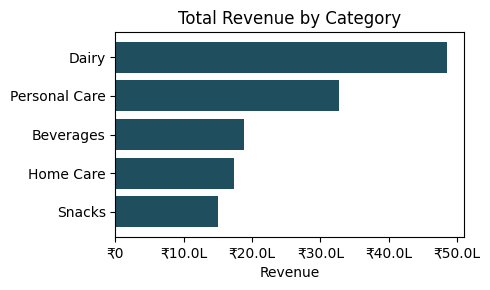

In [25]:
#Revenue by Category (Bar Chart)

def format_inr(x, pos):
    if x >= 1e7:
        return f'₹{x/1e7:.1f}Cr'
    elif x >= 1e5:
        return f'₹{x/1e5:.1f}L'
    return f'₹{x:.0f}'

from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(5, 3))
plt.barh(category_revenue.index, category_revenue.values, color="#1f4e5f")
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_inr))
plt.xlabel("Revenue")
plt.title("Total Revenue by Category")
plt.tight_layout()
plt.show()

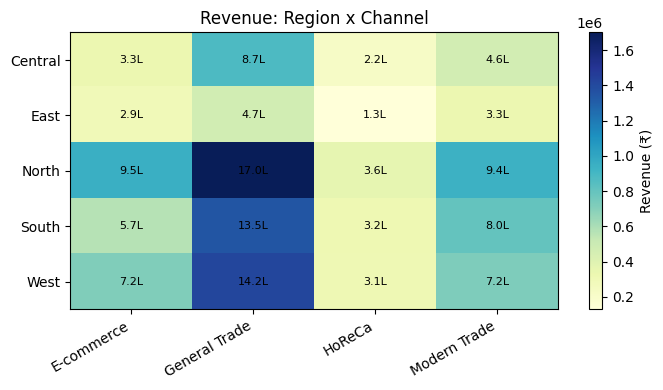

In [20]:
#Region × Channel Heatmap

region_channel = df.pivot_table(
    index="Region",
    columns="Channel",
    values="Revenue",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(7, 4))
plt.imshow(region_channel, cmap="YlGnBu", aspect="auto")

plt.xticks(range(len(region_channel.columns)), region_channel.columns, rotation=30, ha="right")
plt.yticks(range(len(region_channel.index)), region_channel.index)
plt.colorbar(label="Revenue (₹)")
plt.title("Revenue: Region x Channel")

# annotate each cell with its value
for i in range(len(region_channel.index)):
    for j in range(len(region_channel.columns)):
        value = region_channel.iloc[i, j]
        plt.text(j, i, f"{value/1e5:.1f}L", ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()

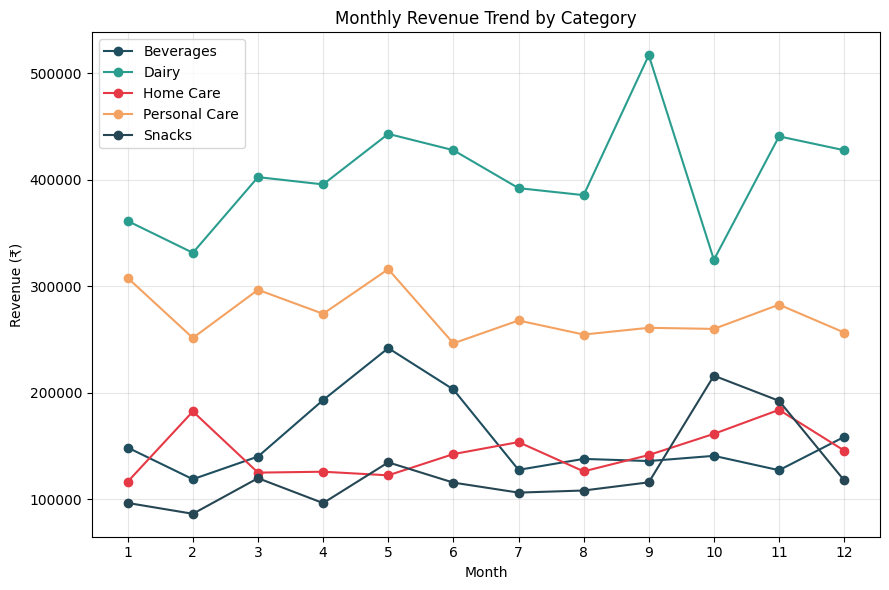

In [21]:
#Monthly Revenue Trend (Line Chart, by Category)

df["Month"] = df["Date"].dt.month

monthly_category = df.pivot_table(
    index="Month",
    columns="Category",
    values="Revenue",
    aggfunc="sum",
    fill_value=0
)

colors = ["#1f4e5f", "#2a9d8f", "#e63946", "#f4a261", "#264653"]  # navy/teal/raspberry-ish palette

plt.figure(figsize=(9, 6))
for i, category in enumerate(monthly_category.columns):
    plt.plot(monthly_category.index, monthly_category[category],
              marker="o", label=category, color=colors[i % len(colors)])

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.title("Monthly Revenue Trend by Category")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

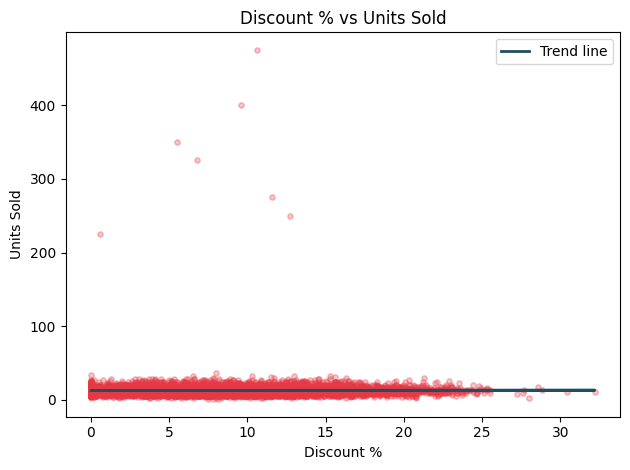

In [ ]:
#Discount vs Units_Sold Scatter Plot

import numpy as np

valid = df.dropna(subset=["Discount_Pct", "Units_Sold"])
z = np.polyfit(valid["Discount_Pct"], valid["Units_Sold"], 1)
trend = np.poly1d(z)

plt.scatter(valid["Discount_Pct"], valid["Units_Sold"], alpha=0.3, s=15, color="#e63946")
plt.plot(valid["Discount_Pct"], trend(valid["Discount_Pct"]), color="#1f4e5f", linewidth=2, label="Trend line")
plt.legend()
plt.xlabel("Discount %")
plt.ylabel("Units Sold")
plt.title("Discount % vs Units Sold")
plt.tight_layout()
plt.show()

In [ ]:
#Insights Summary

top_category = category_summary.index[0]
top_channel = df.groupby("Channel")["Revenue"].sum().idxmax()
peak_month_dairy = monthly_category["Dairy"].idxmax()
corr_value = df["Discount_Pct"].corr(df["Units_Sold"])
outlier_pct = len(outliers) / len(df) * 100

print(f"Top category: {top_category}")
print(f"Top channel: {top_channel}")
print(f"Dairy peak month: {peak_month_dairy}")
print(f"Discount-Units correlation: {corr_value:.3f}")
print(f"Outliers: {outlier_pct:.2f}% of orders")

Top category: Dairy
Top channel: General Trade
Dairy peak month: 9
Discount-Units correlation: 0.006
Outliers: 100.00% of orders


In [ ]:
#Save Cleaned Data
df.to_csv("fmcg_sales_cleaned.csv", index=False)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (8890, 17)


Channel
E-commerce       1577.066383
HoReCa           1500.253150
Modern Trade     1474.394223
General Trade    1454.813594
Name: Revenue, dtype: float64


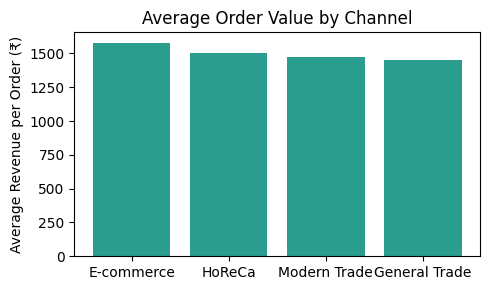

In [ ]:
#Channel-wise Average Order Value (AOV)

channel_aov = df.groupby("Channel")["Revenue"].mean().sort_values(ascending=False)
print(channel_aov)

plt.figure(figsize=(5, 3))
plt.bar(channel_aov.index, channel_aov.values, color="#2a9d8f")
plt.ylabel("Average Revenue per Order (₹)")
plt.title("Average Order Value by Channel")
plt.tight_layout()
plt.show()

In [ ]:
#Top SKU by Revenue

sku_revenue = df.groupby(["Category", "SKU"])["Revenue"].sum().sort_values(ascending=False)

print("Top 5 SKUs:")
print(sku_revenue.head(5))




Top 5 SKUs:
Category  SKU         
Dairy     Butter 100g     1039675.98
          Ice Cream 1L    1017019.59
          Curd 400g       1015882.05
          Milk 500ml       921308.67
          Paneer 200g      857656.05
Name: Revenue, dtype: float64


In [22]:
# bottom SKU by Revenue

sku_revenue = df.groupby(["Category", "SKU"])["Revenue"].sum().sort_values(ascending=False)

print("\nBottom 5 SKUs:")
print(sku_revenue.tail(5))



Bottom 5 SKUs:
Category   SKU          
Beverages  Cola 250ml       453662.43
Snacks     Biscuits 150g    403848.29
           Namkeen 200g     387143.33
           Chips 52g        365014.31
           Cookies 100g     350898.85
Name: Revenue, dtype: float64


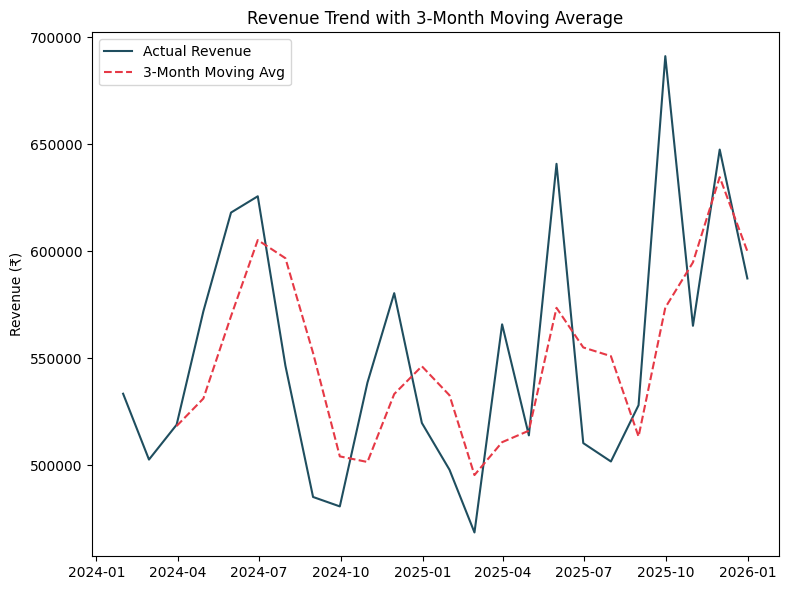

In [23]:
#Simple Moving Average Forecast

monthly_total = df.set_index("Date").resample("ME")["Revenue"].sum()

moving_avg = monthly_total.rolling(window=3).mean()

plt.figure(figsize=(8, 6))
plt.plot(monthly_total.index, monthly_total.values, label="Actual Revenue", color="#1f4e5f")
plt.plot(moving_avg.index, moving_avg.values, label="3-Month Moving Avg", color="#e63946", linestyle="--")
plt.legend()
plt.title("Revenue Trend with 3-Month Moving Average")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.show()